In [2]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go

import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
# import cfpy

In [3]:
from utils.conduits import *
import utils.utils
import importlib
importlib.reload(utils.utils)
from utils.utils import *
from utils.geos import * 

In [150]:
#check sinkhole and spring DEM 
sinkhole_coords = pd.read_csv('../../data/geo_data/bear_sinkholes_coords.txt', delim_whitespace=True, header=None)
spring_coords = pd.read_csv('../../data/geo_data/springs_coords_simple.txt', delim_whitespace=True, header=None)
dem = read_DEM_data('../../data/DEM/dem_1m_m.bil', xmin = x0, xmax = x1, ymin = y0, ymax = y1, dx = 1, dy = 1)

In [151]:
coords = list(zip(sinkhole_coords[0], sinkhole_coords[1]))
sinkhole_z = query_elevation('../../data/DEM/dem_1m_m.bil', coords)
sinkhole_coords['z'] = sinkhole_z
spring_coords['z'] = query_elevation('../../data/DEM/dem_1m_m.bil', list(zip(spring_coords[0], spring_coords[1])))

In [166]:
sinkhole_coords.rename({0 : 'x', 1 : 'y'}, axis=1).to_csv('../../data/geo_data/sinkholes_elev_coords.csv', index=False)

In [21]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [64]:
top =np.load('../../data/DEM/dem_grid_bear_spring.npy').T
model_parameters['domain']['topography'] = top

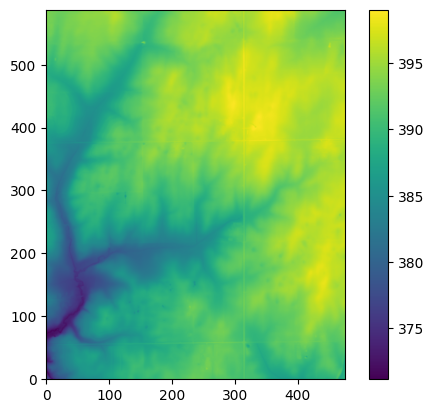

In [51]:
plt.imshow(top, origin = 'lower')
plt.colorbar()

In [22]:
for i in range(5):
    app.model.generate(model_parameters)
    # print(app.model.model_parameters['sks']['seed'])


In [23]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
edges.columns = ['from_id', 'to_id']

In [24]:
edges['y_0'] = nodes.iloc[edges.from_id].reset_index().y
edges['y_1'] = nodes.iloc[edges.to_id].reset_index().y
edges['x_0'] = nodes.iloc[edges.from_id].reset_index().x
edges['x_1'] = nodes.iloc[edges.to_id].reset_index().x
edges['z_0'] = nodes.iloc[edges.from_id].reset_index().z
edges['z_1'] = nodes.iloc[edges.to_id].reset_index().z

lines = edges[["x_0", "y_0", "z_0", "x_1", "y_1", "z_1"]].values
lines = lines.reshape(-1, 2, 3)

In [25]:
nodes.to_csv('../../data/networks/output_dye_trace_sump/nodes.csv', index=False)
edges.to_csv('../../data/networks/output_dye_trace_sump/edges.csv', index=False)

In [ ]:
app.project._get_simulation_data(11)['maps']['karst']

1

In [136]:
agg_map = None
for i in range(1, app.project.n_simulations):
    print(i)
    results = app.project._get_simulation_data(i)
    if agg_map is None:
        agg_map = results['maps']['karst'][0]
    else:
        agg_map += results['maps']['karst'][0]
agg_map /= app.project.n_simulations

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [105]:

nx, ny, nz = agg_map.shape
x, y, z = np.where(agg_map > 0.05)  # keep voxels above threshold

fig = go.Figure(data=go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers',
    marker=dict(
        size=2,
        color=agg_map[x, y, z],  # color by density
        colorscale='Viridis',
        opacity=0.5
    )
))
fig.update_layout(scene=dict(
    xaxis_title='X',
    yaxis_title='Y',
    zaxis_title='Z'
))

In [26]:
import plotly.graph_objects as go
line_traces = []
for line in lines:
    line_traces.append(
        go.Scatter3d(
            x=line[:,0],
            y=line[:,1],
            z=line[:,2],
            mode='lines',
            line=dict(color='blue', width=1),
            showlegend=False
        )
    )
node_type_map = {cat: i for i, cat in enumerate(nodes.type.unique())}
node_colors = nodes.type.map(node_type_map)
# Scatter for nodes
scatter = go.Scatter3d(
    x=nodes.x,
    y=nodes.y,
    z=nodes.z,
    mode='markers',
    marker=dict(
        size=5,
        color=node_colors,  # categorical or numeric
        colorscale='Viridis',
        showscale=True
    )
)

# Combine and plot
fig = go.Figure(data=line_traces + [scatter])
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [34]:
network_path = '../../data/networks/output_dye_trace'
network_agg = None
n = 0
for f in os.listdir(network_path):
    n+=1
    network_dir = f'{network_path}/{f}/network.npy'
    network = np.load(network_dir)
    if network_agg is None:
        network_agg = network
    else:
        network_agg += network
network_agg /= n

Text(0.5, 1.0, 'Conduit distribution, n = 10')

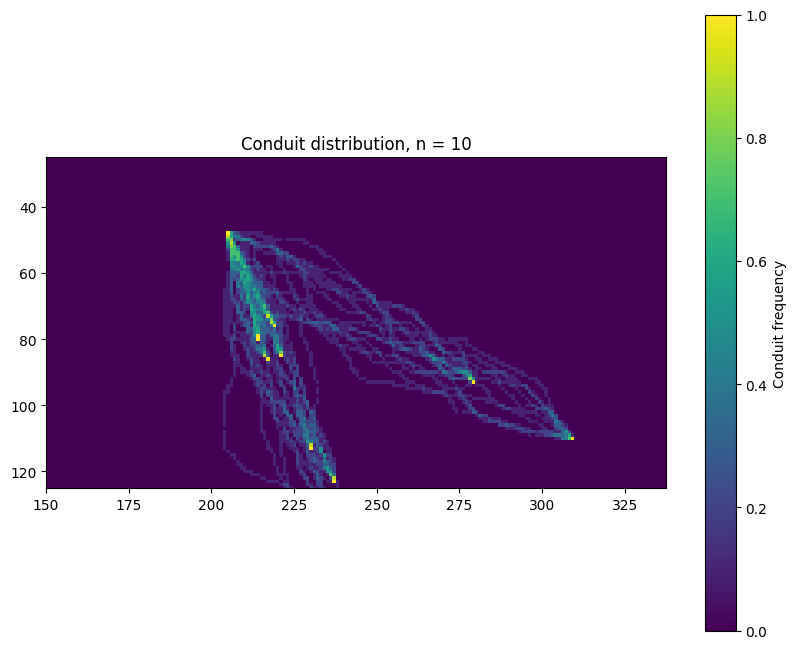

In [ ]:

fig, ax = plt.subplots(figsize = (10,8))
plt.imshow(network_agg)
plt.xlim(150,)
plt.ylim(125,25)
plt.colorbar(label = "Conduit frequency")
plt.title(f"Conduit distribution, n = {n}")
